In [1]:
import os
from pathlib import Path
import geopandas as gpd

In [6]:
# list all the bbox files in a list and generate the centroid points for each bbox, then save the points to a new file
bbox_files = list(Path('/home/GermanCitiesSUHI/data/processed').rglob('*.geojson'))
points = []
for bbox_file in bbox_files:
    gdf = gpd.read_file(bbox_file)
    centroid = gdf.geometry.centroid.iloc[0]
    points.append(centroid)

<Axes: >

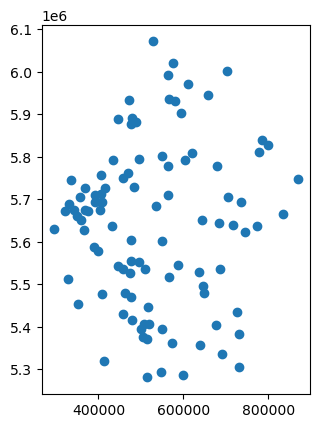

In [7]:
# vis the points
gdf_points = gpd.GeoDataFrame(geometry=points, crs='EPSG:25832')
gdf_points.plot()   

In [8]:
# save the points to a new shp file
gdf_points = gpd.GeoDataFrame(geometry=points, crs='EPSG:25832')
gdf_points.to_file('/home/GermanCitiesSUHI/data/processed/de_centroids.shp', driver='ESRI Shapefile')